IMPORTS

In [ ]:
# ===== Core Python & Utilities =====
import os
import sys
import math
import time
import random
import tempfile
import warnings
import json
from datetime import datetime
from typing import Optional, Tuple, Set
from collections import defaultdict, Counter

# ===== Scientific & Data Handling =====
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr, wilcoxon, ttest_rel

# ===== Machine Learning =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, confusion_matrix,
    accuracy_score, precision_recall_fscore_support, cohen_kappa_score,
    r2_score
)
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer

# ===== Deep Learning =====
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2Tokenizer, GPT2LMHeadModel
)

# ===== Graph Processing =====
import networkx as nx
from tqdm import tqdm

# ===== Visualization =====
import matplotlib.pyplot as plt

# ===== Testing =====
import unittest

# ===== Suppress Warnings =====
warnings.filterwarnings('ignore')

print("Imported all necessary modules successfully")

Imported all necessary modules successfully


parent_count FEATURE ADDITION

In [ ]:
df = pd.read_csv('/content/concat_dataset_final.csv')
display(df.head())

,id,speaker_nm,conversation_id,reply_to_id,reply_to_nm,timestamp,text,likes,shares,num_comments,...,spike_top_entities,spike_external_cause,contextual_relevance,is_reply,user_influence,mention_count,hashtag_count,url_count,conversation_size,conversation_centrality
0,1339230232088367105,MrAndyNgo,1339230232088367105,0,NaN,2020-12-16 15:25:43,BLM-antifa in Seattle have set up another auto...,5200,2700,1400,...,NaN,no_spike,none,0,0.672538,1,0,0,12,0.666667
1,1339230948488073219,Freakoutery,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:28:34,At some point it seems as if we could just sta...,113,2,1,...,NaN,no_spike,none,1,0.049155,0,0,0,12,0.666667
2,1339451172659322882,DevinCow,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-17 06:03:40,Hay \n@KathrynTewson\n they’re lying again,13,0,1,...,"[](10), 'PERSON')](5), trump(4), 'ORG')(3), 'F...",Guardian correlation: How many times has Trump...,general,1,0.006126,1,0,0,12,0.666667
3,1339236439620349957,palindromemood,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:50:23,This is what we have to look forward to in the...,87,5,2,...,NaN,no_spike,none,1,0.043263,0,0,0,12,0.666667
4,1339231536642629632,kmcannistraci,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:30:54,1 time my kid put a note on the door”don’t com...,74,3,10,...,NaN,no_spike,none,1,0.042357,0,0,0,12,0.666667


In [ ]:
def add_parent_count(df, id_col="id", reply_col="reply_to_id"):
    """
    Clean ID and reply columns, then compute parent_count by following
    reply chains upward. No merge() is used (avoid suffix errors).
    """
    df = df.copy()

    # --------------------------------
    # 1. Normalize IDs
    # --------------------------------
    df[id_col] = df[id_col].astype(str).str.strip()

    invalid_tokens = {"", "0", "-1", "nan", "NaN", "None", "none", "<NA>"}
    replies = []

    for val in df[reply_col]:
        if pd.isna(val):
            replies.append(None)
        else:
            s = str(val).strip()
            replies.append(None if s in invalid_tokens else s)

    df[reply_col] = replies

    # --------------------------------
    # 2. Build parent_map
    # --------------------------------
    parent_map = {row[id_col]: row[reply_col] for _, row in df.iterrows()}
    valid_ids = set(parent_map.keys())

    # --------------------------------
    # 3. Compute parent_count for each row
    # --------------------------------
    parent_count_list = []

    for tid in df[id_col]:
        p = parent_map.get(tid)
        visited = set()
        count = 0

        while p is not None and p in valid_ids and p not in visited:
            visited.add(p)
            count += 1
            p = parent_map.get(p)

        parent_count_list.append(count)

    # --------------------------------
    # 4. Assign parent_count directly
    # --------------------------------
    df["parent_count"] = parent_count_list

    return df

df = add_parent_count(df, id_col="id", reply_col="reply_to_id")
print(df[["id","reply_to_id","parent_count"]].head())


                    id          reply_to_id  parent_count
0  1339230232088367105                 None             0
1  1339230948488073219  1339230232088367105             1
2  1339451172659322882  1339230232088367105             1
3  1339236439620349957  1339230232088367105             1
4  1339231536642629632  1339230232088367105             1


In [ ]:
dist = df['parent_count'].value_counts().sort_index().reset_index()
dist.columns = ["parent_count", "count"]
dist['percentage'] = (dist['count'] / len(df) * 100).round(2)

print(dist)

   parent_count  count  percentage
0             0    314       14.48
1             1   1842       84.92
2             2     13        0.60


In [ ]:
df.head() # note: it has a new feature: parent_count

,id,speaker_nm,conversation_id,reply_to_id,reply_to_nm,timestamp,text,likes,shares,num_comments,...,spike_external_cause,contextual_relevance,is_reply,user_influence,mention_count,hashtag_count,url_count,conversation_size,conversation_centrality,parent_count
0,1339230232088367105,MrAndyNgo,1339230232088367105,None,NaN,2020-12-16 15:25:43,BLM-antifa in Seattle have set up another auto...,5200,2700,1400,...,no_spike,none,0,0.672538,1,0,0,12,0.666667,0
1,1339230948488073219,Freakoutery,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:28:34,At some point it seems as if we could just sta...,113,2,1,...,no_spike,none,1,0.049155,0,0,0,12,0.666667,1
2,1339451172659322882,DevinCow,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-17 06:03:40,Hay \n@KathrynTewson\n they’re lying again,13,0,1,...,Guardian correlation: How many times has Trump...,general,1,0.006126,1,0,0,12,0.666667,1
3,1339236439620349957,palindromemood,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:50:23,This is what we have to look forward to in the...,87,5,2,...,no_spike,none,1,0.043263,0,0,0,12,0.666667,1
4,1339231536642629632,kmcannistraci,1339230232088367105,1339230232088367105,MrAndyNgo,2020-12-16 15:30:54,1 time my kid put a note on the door”don’t com...,74,3,10,...,no_spike,none,1,0.042357,0,0,0,12,0.666667,1


TRAIN TEST SPLIT- ONLY THOSE WITH 1 PARENT ARE TEST , REST ARE TRAIN

In [ ]:

TRAIN_RATIO = 0.95
def tgn_train_test_split(
    df,
    timestamp_col="timestamp",
    min_parents_for_test=1,
    train_ratio=TRAIN_RATIO
):
    """
    Splits dataframe into train/test for TGN:
      - Train: all tweets (roots + replies)
      - Test: only tweets with parent_count >= min_parents_for_test
    """

    df = df.copy()

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce') # Ensure timestamp is datetime
    df = df.sort_values(timestamp_col).reset_index(drop=True)

    split_idx = int(len(df) * train_ratio)

    train_df = df.iloc[:split_idx].copy()
    test_raw  = df.iloc[split_idx:].copy()
    test_df = test_raw[test_raw["parent_count"] >= min_parents_for_test].copy()

    print(f"Total rows: {len(df)}")
    print(f"Train rows: {len(train_df)}")
    print(f"Test rows (replies only): {len(test_df)}")

    return train_df, test_df

train_df, test_df = tgn_train_test_split(df)


Total rows: 2169
Train rows: 2060
Test rows (replies only): 94


BUILD TGN

In [ ]:
# ============================================================
# HELPER FUNCTION: TIMESTAMP PARSER
# ============================================================
def parse_timestamp(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, (pd.Timestamp, datetime)):
        return pd.Timestamp(x)

    s = str(x)
    formats = [
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%dT%H:%M:%S",
        "%Y-%m-%d",
        "%d/%m/%Y %H:%M:%S"
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.to_datetime(s, errors="coerce")


# ============================================================
# ADD PARENT COUNT
# ============================================================
def add_parent_count(df, id_col="id", reply_col="reply_to_id"):
    df = df.copy()

    df[id_col] = df[id_col].astype(str).str.strip()

    invalid = {"", "0", "-1", "nan", "NaN", "None", "none", "<NA>"}
    cleaned = []
    for val in df[reply_col]:
        if pd.isna(val):
            cleaned.append(None)
        else:
            sv = str(val).strip()
            cleaned.append(None if sv in invalid else sv)
    df[reply_col] = cleaned

    parent_map = {row[id_col]: row[reply_col] for _, row in df.iterrows()}
    valid_ids = set(parent_map.keys())

    counts = []
    for tid in df[id_col]:
        p = parent_map.get(tid)
        visited = set()
        c = 0
        while p is not None and p in valid_ids and p not in visited:
            visited.add(p)
            c += 1
            p = parent_map.get(p)
        counts.append(c)

    df["parent_count"] = counts
    return df


# ============================================================
# METRIC CALCULATIONS
# ============================================================
def calculate_hate_intensity(row):
    if pd.notna(row.get("hate_intensity")) and row["hate_intensity"] > 0:
        return float(row["hate_intensity"])

    sentiment = row.get("sentiment", 0) or 0
    base = max(0, (1 - sentiment) / 2) if sentiment != 0 else 0.3

    keywords = row.get("hate_keywords_count", 0) or 0
    kw_boost = min(0.3, keywords * 0.1)

    viral = row.get("viral_score", row.get("virality_score", 0)) or 0
    viral_boost = min(0.2, viral * 0.1)

    likes = row.get("likes", 0) or 0
    shares = row.get("shares", 0) or 0
    comments = row.get("num_comments", 0) or 0
    engagement = likes + shares * 3 + comments * 2
    eng_boost = min(0.15, engagement / 10000)

    final = base + kw_boost + viral_boost + eng_boost + random.uniform(-0.05, 0.05)
    return max(0, min(1, final))


def calculate_user_influence(row):
    if pd.notna(row.get("user_influence")) and row["user_influence"] > 0:
        return float(row["user_influence"])

    likes = row.get("likes", 0) or 0
    shares = row.get("shares", 0) or 0
    comments = row.get("num_comments", 0) or 0

    engagement = likes + shares * 5 + comments * 3
    base = min(0.7, engagement / 5000)

    viral = row.get("viral_score", row.get("virality_score", 0)) or 0
    viral_boost = min(0.2, viral * 0.1)

    rank = row.get("engagement_rank", 100) or 100
    rank_boost = max(0, 0.1 * (100 - min(100, rank)) / 100)

    centrality = row.get("conversation_centrality", 0) or 0
    centrality_boost = min(0.1, centrality * 0.2)

    final = base + viral_boost + rank_boost + centrality_boost + random.uniform(-0.05, 0.05)
    return max(0.01, min(1.0, final))


# ============================================================
# EDGE BUILDER
# ============================================================
def add_edge(G, source, target, relation_type, timestamp):
    if source not in G.nodes or target not in G.nodes:
        return

    s_h = float(G.nodes[source].get("hate_intensity", 0))
    t_h = float(G.nodes[target].get("hate_intensity", 0))
    s_inf = float(G.nodes[source].get("user_influence", 0))
    t_inf = float(G.nodes[target].get("user_influence", 0))

    hate_corr = min(1, s_h * t_h * 1.5)
    hate_prop = t_h - s_h
    influence_flow = t_inf - s_inf
    influence_prod = s_inf * t_inf

    weight = {"reply": 1.0, "conversation_flow": 0.8, "mention": 0.6}.get(relation_type, 0.5)

    G.add_edge(
        source,
        target,
        relation=relation_type,
        timestamp=timestamp,
        hate_correlation=hate_corr,
        hate_propagation=hate_prop,
        influence_flow=influence_flow,
        influence_product=influence_prod,
        weight=weight,
    )


# ============================================================
# NODE BUILDER
# ============================================================
def add_node(G, row, added_edges):
    node_id = str(row["id"])
    convo_id = str(row.get("conversation_id", node_id))
    parent = row.get("reply_to_id")
    parent = None if pd.isna(parent) else str(parent)

    # ---- CREATE NODE ----
    if node_id not in G.nodes:
        hi = calculate_hate_intensity(row)
        ui = calculate_user_influence(row)

        is_amp = (
            (hi > 0.6 and ui > 0.6) or
            (row.get("viral_score", 0) > 0.8 and hi > 0.5)
        )

        G.add_node(
            node_id,
            text=row.get("text", ""),
            timestamp=parse_timestamp(row.get("timestamp")),
            speaker=row.get("speaker_nm", "Unknown"),
            cleaned_text=row.get("cleaned_text", ""),

            likes=row.get("likes", 0),
            shares=row.get("shares", 0),
            num_comments=row.get("num_comments", 0),

            hate_intensity=hi,
            user_influence=ui,
            viral_score=row.get("viral_score", 0),

            sentiment=row.get("sentiment", 0),
            hate_keywords_count=row.get("hate_keywords_count", 0),

            conversation_id=convo_id,
            reply_to_id=parent,
            parent_count=row.get("parent_count", 0),
            conversation_centrality=row.get("conversation_centrality", 0),

            is_amplifier=is_amp,
        )

    # ---- ADD EDGES ----
    ts = G.nodes[node_id]["timestamp"]

    # reply edge
    if parent and parent in G.nodes and G.nodes[parent]["conversation_id"] == convo_id:
        key = (parent, node_id, "reply")
        if key not in added_edges:
            add_edge(G, parent, node_id, "reply", ts)
            added_edges.add(key)

    # conversation flow edge
    convo_nodes = [
        n for n in G.nodes
        if n != node_id and G.nodes[n]["conversation_id"] == convo_id
    ]

    if convo_nodes:
        last_node = max(convo_nodes, key=lambda n: G.nodes[n]["timestamp"])
        key = (last_node, node_id, "conversation_flow")
        if key not in added_edges:
            add_edge(G, last_node, node_id, "conversation_flow", ts)
            added_edges.add(key)

    return added_edges


# ============================================================
# BUILD TGN
# ============================================================
def build_tgn(df, isTest=False):
    G = nx.DiGraph()
    added_edges = set()

    for _, row in df.iterrows():
        added_edges = add_node(G, row, added_edges)

    for nid in G.nodes:
        G.nodes[nid]["is_test"] = isTest
        G.nodes[nid]["is_train"] = not isTest

    return G, added_edges

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
def tgn_train_test_split(df, timestamp_col="timestamp", train_ratio=TRAIN_RATIO):
    df = df.copy()

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.sort_values(timestamp_col)

    split = int(len(df) * train_ratio)
    train_df = df.iloc[:split]
    test_df = df.iloc[split:]

    return train_df, test_df

# ============================================================
# RUN EVERYTHING
# ============================================================
df = add_parent_count(df)

numeric_cols = ["likes", "shares", "num_comments", "hate_intensity", "sentiment", "hate_keywords_count", "virality_score", "engagement_rank"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

train_df, test_df = tgn_train_test_split(df)
test_df = test_df[test_df["parent_count"] >= 1].copy()

G_train, edges_train = build_tgn(train_df, isTest=False)
G_test, edges_test = build_tgn(test_df, isTest=True)


# PRINT
print("\n=========== TRAIN GRAPH ===========")
print("Nodes:", len(G_train.nodes))
print("Edges:", len(G_train.edges))

print("\n=========== TEST GRAPH ===========")
print("Nodes:", len(G_test.nodes))
print("Edges:", len(G_test.edges))

print("\nTGN graphs built successfully!")



=========== TRAIN GRAPH ===========
Nodes: 2024
Edges: 3209

=========== TEST GRAPH ===========
Nodes: 94
Edges: 65

TGN graphs built successfully!


INSIGHTS INTO TGN

In [ ]:
def show_nodes(G, n=10):
    print("\n==================== NODES ====================")
    count = 0
    for node, data in G.nodes(data=True):
        print(f"\nNode ID: {node}")
        for k, v in data.items():
            print(f"   {k:25} : {v}")
        count += 1
        if count >= n:
            break
    print("================================================\n")

def show_edges(G, n=10):
    print("\n==================== EDGES ====================")
    count = 0
    for u, v, data in G.edges(data=True):
        print(f"\nEdge: {u}  -->  {v}")
        for k, v2 in data.items():
            print(f"   {k:25} : {v2}")
        count += 1
        if count >= n:
            break
    print("================================================\n")

show_nodes(G_train, n=2)
show_edges(G_train, n=2)



==================== NODES ====================

Node ID: 1265323293361541121
   text                      : All Lives Matter is an ideal.

Black Lives Matter is an organization & activism committed to ensuring that Black lives become a part of the ALL.

#GeorgeFloyd’s last breath screams to us today that Black lives are not indiscriminately among the ALL.

Do #BlackLivesMatter to you?
   timestamp                 : 2020-05-26 16:45:56
   speaker                   : BerniceKing
   cleaned_text              : lives matter ideal black lives matter organization activism committed ensuring black lives georgefloyds breath screams today black lives indiscriminately blacklivesmatter
   likes                     : 9200
   shares                    : 3100
   num_comments              : 224
   hate_intensity            : 0.1
   user_influence            : 0.434351134306872
   viral_score               : 0
   sentiment                 : 0.08
   hate_keywords_count       : 0
   conversation_id   

In [ ]:
def print_top_hate_nodes(graph, k=2):
    sorted_nodes = sorted(
        graph.nodes(data=True),
        key=lambda x: x[1].get("hate_intensity", 0),
        reverse=True
    )[:k]

    print("\n====== TOP {} HIGH-HATE NODES ======".format(k))
    for node_id, data in sorted_nodes:
        print(f"\nNode ID: {node_id}")
        print(f"   hate_intensity        : {data.get('hate_intensity')}")
        print(f"   text                  : {data.get('text')[:120]}...")
        print(f"   user_influence        : {data.get('user_influence')}")
        print(f"   sentiment             : {data.get('sentiment')}")
        print(f"   conversation_id       : {data.get('conversation_id')}")
        print("-"*60)

print_top_hate_nodes(G_train)



====== TOP 2 HIGH-HATE NODES ======

Node ID: 1274489578968289281
   hate_intensity        : 1.0
   text                  : Time to turn the tide America. The Marxists Are Winning – What Black Lives Matter Really Wants - 
@realDonaldTrump
 #Tru...
   user_influence        : 0.0068280444025189
   sentiment             : 0.177777777777778
   conversation_id       : 1274489578968289281
------------------------------------------------------------

Node ID: 1277819384325701632
   hate_intensity        : 1.0
   text                  : Exactly didn't everyone see all the DEMOCRAT/LIBERAL WHITE SUPREMACISTS rioting, vandalising businesses, attacking peopl...
   user_influence        : 0.1585803192130562
   sentiment             : 0.0625
   conversation_id       : 1274488129907556358
------------------------------------------------------------


In [ ]:
def print_top_hate_edges(graph, k=2):
    sorted_edges = sorted(
        graph.edges(data=True),
        key=lambda x: x[2].get("hate_propagation", 0),
        reverse=True
    )[:k]

    print("\n====== TOP {} HIGH-HATE EDGES ======".format(k))
    for src, dst, data in sorted_edges:
        print(f"\nEdge: {src} --> {dst}")
        print(f"   hate_propagation      : {data.get('hate_propagation')}")
        print(f"   relation              : {data.get('relation')}")
        print(f"   influence_flow        : {data.get('influence_flow')}")
        print(f"   weight                : {data.get('weight')}")
        print("-"*60)
print_top_hate_edges(G_train)



====== TOP 2 HIGH-HATE EDGES ======

Edge: 1277818496391483402 --> 1277819384325701632
   hate_propagation      : 0.9
   relation              : conversation_flow
   influence_flow        : 0.055470738013968096
   weight                : 0.8
------------------------------------------------------------

Edge: 1341017254679474176 --> 1341017275348955143
   hate_propagation      : 0.8594437071128204
   relation              : conversation_flow
   influence_flow        : 0.010170723526860402
   weight                : 0.8
------------------------------------------------------------


In [ ]:
def print_top_influential_nodes(graph, k=2):
    sorted_nodes = sorted(
        graph.nodes(data=True),
        key=lambda x: x[1].get("network_influence", 0),
        reverse=True
    )[:k]

    print("\n====== TOP {} INFLUENTIAL NODES ======".format(k))
    for node_id, data in sorted_nodes:
        print(f"\nNode ID: {node_id}")
        print(f"   network_influence     : {data.get('network_influence')}")
        print(f"   pagerank              : {data.get('pagerank')}")
        print(f"   degree_centrality     : {data.get('degree_centrality')}")
        print(f"   text                  : {data.get('text')[:120]}...")
        print("-"*60)
print_top_influential_nodes(G_train)



====== TOP 2 INFLUENTIAL NODES ======

Node ID: 1265323293361541121
   network_influence     : None
   pagerank              : None
   degree_centrality     : None
   text                  : All Lives Matter is an ideal.

Black Lives Matter is an organization & activism committed to ensuring that Black lives b...
------------------------------------------------------------

Node ID: 1265323872368447489
   network_influence     : None
   pagerank              : None
   degree_centrality     : None
   text                  : That was the Awesomest way to put this! Simple but perfect!!...
------------------------------------------------------------


Graph has 2024 nodes → plotting largest conversation only


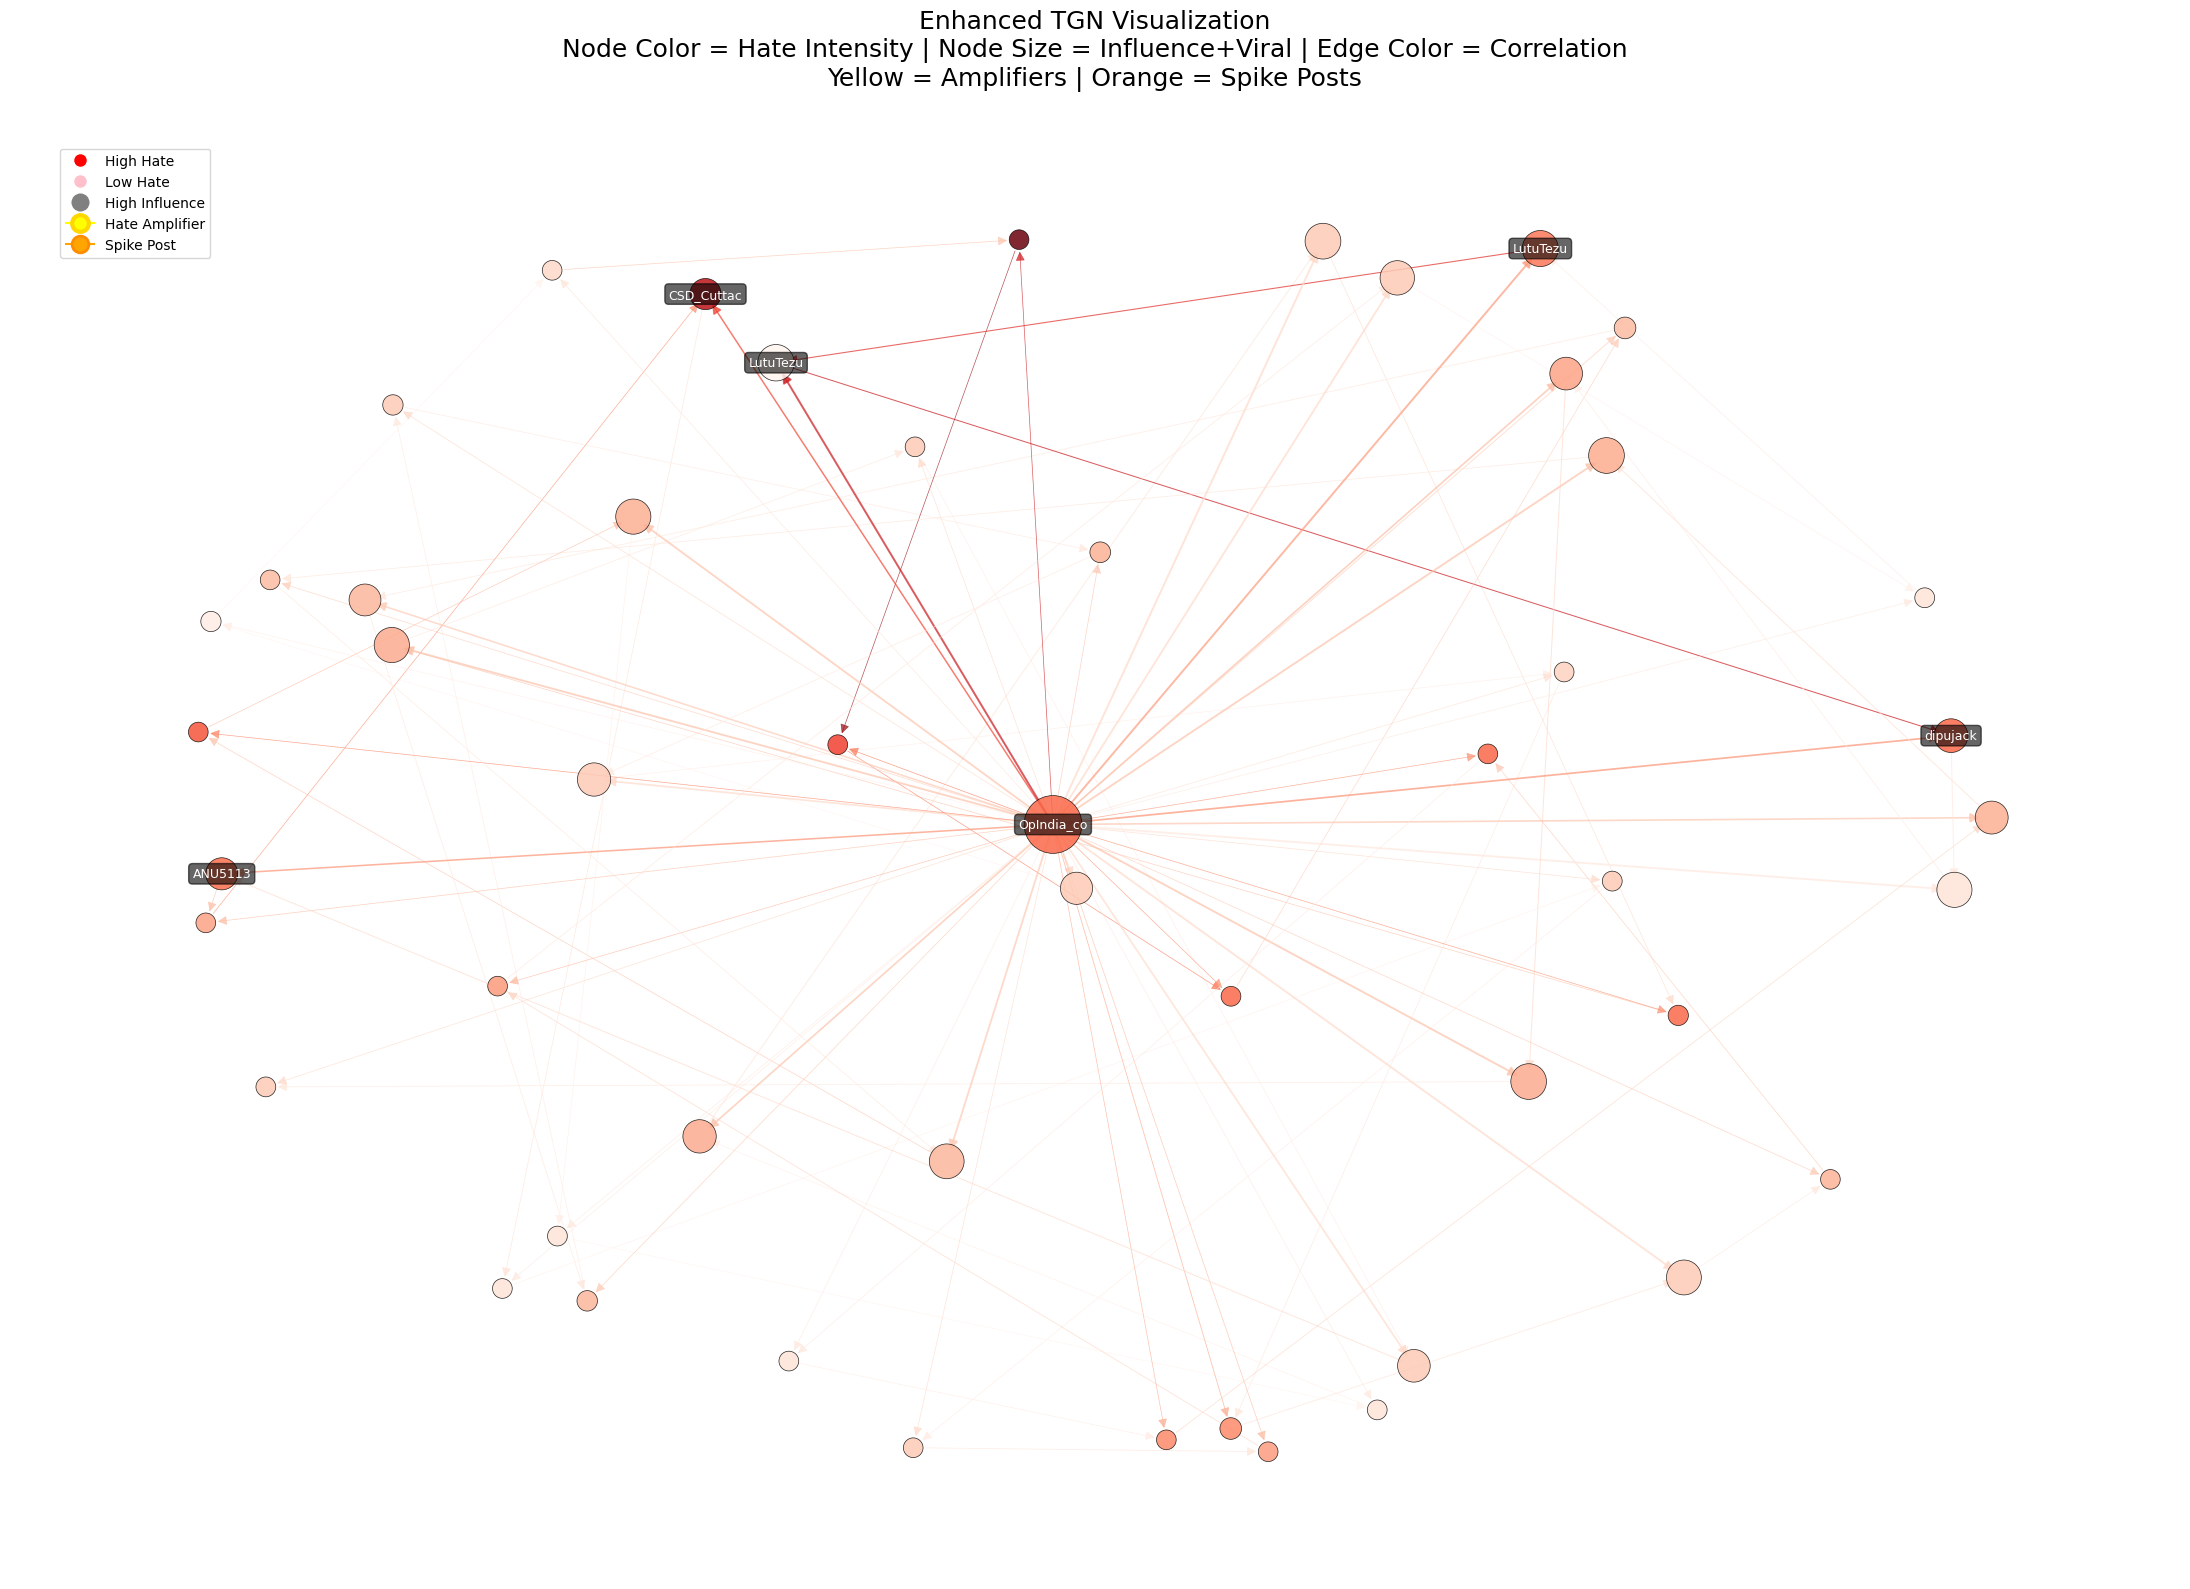

In [ ]:
def visualize_tgn(G, max_nodes=150):
    """
    Visualize the Temporal Graph Network (TGN)
    Compact, readable, and scalable for medium-sized graphs.
    """

    # -------------------------
    # 1. SUBGRAPH SELECTION
    # -------------------------
    if len(G.nodes()) > max_nodes:
        print(f"Graph has {len(G.nodes())} nodes → plotting largest conversation only")

        largest_cc = max(nx.weakly_connected_components(G), key=len) # Pick largest connected component
        G = G.subgraph(largest_cc).copy()

    plt.figure(figsize=(22, 16))

    # -------------------------
    # 2. Layout
    # -------------------------
    pos = nx.spring_layout(G, seed=42, k=1.2, iterations=60)

    # -------------------------
    # 3. Construct node features
    # -------------------------
    node_colors = []
    node_sizes = []

    for node, data in G.nodes(data=True):

        # hate intensity → red shade
        hate = data.get("hate_intensity", 0)
        node_colors.append(plt.cm.Reds(min(max(hate, 0), 1)))

        # size = influence + viral score
        influence = data.get("user_influence", 0)
        viral = data.get("viral_score", 0)
        size = 200 + 2000 * (influence + viral)

        # clamp size
        node_sizes.append(min(size, 3000))

    # -------------------------
    # 4. Edge features
    # -------------------------
    edge_colors = []
    edge_widths = []

    for u, v, data in G.edges(data=True):
        hate_corr = data.get("hate_correlation", 0)
        influence_prod = data.get("influence_product", 0)

        edge_colors.append(plt.cm.Reds(min(max(hate_corr, 0), 1)))
        edge_widths.append(0.5 + 5 * influence_prod)

    # -------------------------
    # 5. Basic drawing
    # -------------------------
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.85
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.7,
        arrowsize=14
    )

    # -------------------------
    # 6. Highlight Amplifiers
    # -------------------------
    amplifiers = [n for n in G.nodes() if G.nodes[n].get("is_amplifier", False)]
    if amplifiers:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=amplifiers,
            node_color="yellow",
            node_size=[node_sizes[list(G.nodes()).index(n)] for n in amplifiers],
            alpha=0.4,
            edgecolors="gold",
            linewidths=3
        )

    # -------------------------
    # 7. Highlight Spike Nodes
    # -------------------------
    spike_nodes = [n for n in G.nodes() if G.nodes[n].get("spike_day", False)]
    if spike_nodes:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=spike_nodes,
            node_color="orange",
            node_size=[node_sizes[list(G.nodes()).index(n)] for n in spike_nodes],
            alpha=0.5,
            edgecolors="darkorange",
            linewidths=2
        )

    # -------------------------
    # 8. Label top-most important nodes
    # -------------------------
    top_nodes = sorted(
        G.nodes(),
        key=lambda n: G.nodes[n].get("user_influence", 0) * G.nodes[n].get("hate_intensity", 0),
        reverse=True
    )[:6]

    labels = {n: G.nodes[n].get("speaker", "")[:10] for n in top_nodes}

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_color="white",
        bbox=dict(boxstyle="round", facecolor="black", alpha=0.6)
    )

    # -------------------------
    # 9. Title & Legend
    # -------------------------
    plt.title(
        "Enhanced TGN Visualization\n"
        "Node Color = Hate Intensity | Node Size = Influence+Viral | Edge Color = Correlation\n"
        "Yellow = Amplifiers | Orange = Spike Posts",
        fontsize=18,
        pad=20
    )

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='white', markerfacecolor='red', markersize=10, label="High Hate"),
        plt.Line2D([0], [0], marker='o', color='white', markerfacecolor='pink', markersize=10, label="Low Hate"),
        plt.Line2D([0], [0], marker='o', color='white', markerfacecolor='gray', markersize=14, label="High Influence"),
        plt.Line2D([0], [0], marker='o', color='yellow', markeredgecolor='gold', markeredgewidth=3,
                   markersize=12, label="Hate Amplifier"),
        plt.Line2D([0], [0], marker='o', color='orange', markeredgecolor='darkorange', markeredgewidth=2,
                   markersize=12, label="Spike Post"),
    ]

    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98))
    plt.axis("off")
    plt.tight_layout()
    plt.show()
visualize_tgn(G_train, max_nodes=100)


In [ ]:
def analyze_temporal_patterns(G, time_window='day'):
    """
    Analyze temporal patterns (daily/hourly) of the TGN graph.
    Computes:
        • hate statistics  (avg, max, median, std)
        • viral statistics
        • tweet volumes per time bin
        • spike detection + metadata
    """
    time_bins = defaultdict(lambda: { # Container for time-binned stats
        'hate_scores': [],
        'viral_scores': [],
        'spike_events': []
    })

    # --------------------------
    # 1. Bin all nodes by time
    # --------------------------
    for node, data in G.nodes(data=True):

        timestamp = data.get("timestamp")
        if timestamp is None:
            continue

        # Choose granularity
        if time_window == "hour":
            date_key = timestamp.strftime("%Y-%m-%d %H:00")
        else:
            date_key = timestamp.strftime("%Y-%m-%d")

        hate = data.get('hate_intensity', 0)
        viral = data.get('viral_score', 0)

        time_bins[date_key]['hate_scores'].append(hate)
        time_bins[date_key]['viral_scores'].append(viral)

        # ------------- Spike Logic -------------
        is_spike = (
            bool(data.get('spike_day')) or
            viral > 0.70
        )

        if is_spike:
            ents_raw = data.get("spike_top_entities", [])
            if isinstance(ents_raw, str):
                ents = [e.strip() for e in ents_raw.split(",") if e.strip()]
            else:
                ents = ents_raw or []

            spike_event = {
                "cause": data.get("spike_cause", "Unknown"),
                "entities": ents,
                "external_cause": data.get("spike_external_cause", ''),
                "contextual_relevance": data.get("contextual_relevance", 'none')
            }
            time_bins[date_key]['spike_events'].append(spike_event)

    # -----------------------------
    # 2. Compute final time metrics
    # -----------------------------
    temporal_metrics = {}

    for date, vals in sorted(time_bins.items()):

        hate_scores = vals["hate_scores"]
        viral_scores = vals["viral_scores"]

        temporal_metrics[date] = {
            "tweet_count": len(hate_scores),

            # Hate metrics
            "avg_hate": float(np.mean(hate_scores)) if hate_scores else 0,
            "max_hate": float(np.max(hate_scores)) if hate_scores else 0,
            "min_hate": float(np.min(hate_scores)) if hate_scores else 0,
            "median_hate": float(np.median(hate_scores)) if hate_scores else 0,
            "std_hate": float(np.std(hate_scores)) if hate_scores else 0,

            # Viral score
            "avg_viral": float(np.mean(viral_scores)) if viral_scores else 0,

            # Spike details
            "spike_events": vals['spike_events'],
            "num_spike_events": len(vals['spike_events'])
        }

    return temporal_metrics
temporal_stats = analyze_temporal_patterns(G_train, time_window='day')
for day, stats in temporal_stats.items():
    print(day, stats)
    break   # shows only 1 tweet


2020-05-26 {'tweet_count': 25, 'avg_hate': 0.31516794874393117, 'max_hate': 0.65, 'min_hate': 0.1, 'median_hate': 0.3, 'std_hate': 0.17133334457104693, 'avg_viral': 0.0, 'spike_events': [], 'num_spike_events': 0}


PREDICTION OF FUTURE NODES


In [ ]:
def extract_test_nodes(G_test):
    """
    Extract only the nodes that belong to the test set.
    Assumes build_tgn() sets data['is_test'] = True for test nodes.
    Returns: dict {node_id: full_text}
    """
    test_nodes = {}

    for n, data in G_test.nodes(data=True):
        if data.get("is_test", False):
            text = data.get("full_text", "")
            test_nodes[n] = text

    return test_nodes
test_nodes = extract_test_nodes(G_test)
print("Test nodes:", len(test_nodes))


Test nodes: 94


In [ ]:
results = [] #store all results in an array for final comparison

In [ ]:
# -----------------------
# SETTINGS
# -----------------------
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Model configurations
ETHOS_MODEL = "s-nlp/roberta_toxicity_classifier"
GEN_MODEL = "gpt2"
DISTIL_GEN_MODEL = "distilgpt2"
ALT_CLASS_MODEL = "Hate-speech-CNERG/dehatebert-mono-english"

SAMPLE_LIMIT = None  # Set to None for full dataset

# -----------------------
# Model Loading Utilities
# -----------------------
def safe_load_classification(model_name):
    """Load a classification model with proper tokenizer setup."""
    print(f"Loading classifier: {model_name}")
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.add_special_tokens({"pad_token": "[PAD]"})
        model.resize_token_embeddings(len(tok))
    model.to(DEVICE)
    model.eval()
    return tok, model

def safe_load_gpt2_like(model_name):
    """Load a GPT-2 style generative model with proper tokenizer setup."""
    print(f"Loading generator: {model_name}")
    tok = GPT2Tokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.add_special_tokens({"pad_token": "[PAD]"})
    model = GPT2LMHeadModel.from_pretrained(model_name)
    model.resize_token_embeddings(len(tok))
    model.to(DEVICE)
    model.eval()
    return tok, model

# -----------------------
# Prediction Functions
# -----------------------
def classifier_predict(tokenizer, model, text, max_length=128):
    """
    Predict class and intensity for given text using a classification model.

    Args:
        tokenizer: Tokenizer for the model
        model: Classification model
        text: Input text string
        max_length: Maximum sequence length

    Returns:
        class_id: Predicted class ID
        intensity: Normalized intensity score (0-1)
        probs: Full probability distribution
    """
    if not text or text.strip() == "":
        text = "."

    enc = tokenizer(text, return_tensors="pt", truncation=True,
                   padding="longest", max_length=max_length)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = model(**enc)
        logits = out.logits
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    if probs.ndim == 0:
        probs = np.array([probs])

    class_id = int(np.argmax(probs))
    n_labels = probs.shape[0]
    intensity = float(class_id / max(1.0, (n_labels - 1))) if n_labels > 1 else 0.0

    return class_id, intensity, probs

def generate_text_with_model(tokenizer, model, prompt, max_length=80,
                            top_p=0.92, temp=0.85):
    """
    Generate text continuation using a language model.

    Args:
        tokenizer: Tokenizer for the model
        model: Generative language model
        prompt: Input prompt text
        max_length: Maximum length to generate
        top_p: Nucleus sampling parameter
        temp: Temperature for sampling

    Returns:
        generated: Generated text (without the prompt)
    """
    if not prompt or prompt.strip() == "":
        prompt = "."

    enc = tokenizer(prompt, return_tensors="pt", truncation=True,
                   padding=True, max_length=128)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    pad_id = tokenizer.eos_token_id if tokenizer.pad_token_id is None else tokenizer.pad_token_id

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_length=min(256, enc["input_ids"].shape[1] + max_length),
            do_sample=True,
            top_p=top_p,
            temperature=temp,
            num_return_sequences=1,
            pad_token_id=pad_id
        )

    generated = tokenizer.decode(out[0], skip_special_tokens=True)
    if generated.startswith(prompt):
        generated = generated[len(prompt):].strip()
    if len(generated) < 2:
        generated = "."

    return generated

def extract_test_nodes(G_test):
    """
    Extract test nodes from the graph.

    Args:
        G_test: NetworkX graph with test nodes marked

    Returns:
        List of tuples (node_id, text)
    """
    nodes = []
    for n, data in G_test.nodes(data=True):
        if data.get("is_test", False):
            txt = data.get("full_text") or data.get("text") or "."
            nodes.append((str(n), txt))
    return nodes

# -----------------------
# Pipeline Execution
# -----------------------
def run_pipeline(G_test, classifier_tok, classifier_model,
                gen_tok, gen_model, sample_limit=None, name="Pipeline"):
    """
    Run complete pipeline: extract nodes, generate text, classify both original and generated.

    Args:
        G_test: Test graph
        classifier_tok: Classifier tokenizer
        classifier_model: Classification model
        gen_tok: Generator tokenizer
        gen_model: Generative model
        sample_limit: Optional limit on number of samples
        name: Name for this pipeline run

    Returns:
        DataFrame with results for each test node
    """
    test_nodes = extract_test_nodes(G_test)
    if sample_limit:
        test_nodes = test_nodes[:sample_limit]

    print(f"\n=== Running {name} ===")
    print(f"Processing {len(test_nodes)} test nodes...")

    records = []
    for node_id, text in tqdm(test_nodes, desc=name):
        # Classify original text
        orig_class, orig_intensity, _ = classifier_predict(classifier_tok, classifier_model, text)

        # Generate new text
        gen_text = generate_text_with_model(gen_tok, gen_model, text[:400])

        # Classify generated text
        gen_class, gen_intensity, _ = classifier_predict(classifier_tok, classifier_model, gen_text)

        records.append({
            "node_id": node_id,
            "orig_text": text,
            "gen_text": gen_text,
            "orig_class": int(orig_class),
            "orig_intensity": float(orig_intensity),
            "gen_class": int(gen_class),
            "gen_intensity": float(gen_intensity),
            "class_changed": int(orig_class != gen_class),
            "intensity_diff": abs(gen_intensity - orig_intensity)
        })

    return pd.DataFrame(records)

# -----------------------
# Advanced Metrics Calculation
# -----------------------
def calculate_advanced_metrics(results_df, model_name):
    """
    Calculate comprehensive metrics for model evaluation.

    Args:
        results_df: DataFrame with prediction results
        model_name: Name of the model for labeling

    Returns:
        Dictionary of metrics
    """
    y_true = results_df["orig_intensity"].values
    y_pred = results_df["gen_intensity"].values
    y_true_cls = results_df["orig_class"].values
    y_pred_cls = results_df["gen_class"].values

    # Regression metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)

    # Correlation metrics
    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_r, spearman_p = spearmanr(y_true, y_pred)

    # Classification metrics
    accuracy = accuracy_score(y_true_cls, y_pred_cls)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_cls, y_pred_cls, average='weighted', zero_division=0
    )
    kappa = cohen_kappa_score(y_true_cls, y_pred_cls)

    # Additional metrics
    class_change_rate = results_df["class_changed"].mean()
    mean_intensity_diff = results_df["intensity_diff"].mean()

    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    metrics = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r_squared,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ClassChangeRate": class_change_rate,
        "MeanIntensityDiff": mean_intensity_diff,
        "N_Samples": len(results_df)
    }

    results.append(metrics)
    return metrics

# -----------------------
# Statistical Significance Tests
# -----------------------
def perform_statistical_tests(main_results, baseline1_results, baseline2_results):
    """
    Perform statistical significance tests comparing main model to baselines.

    Args:
        main_results: Results DataFrame for main model
        baseline1_results: Results DataFrame for baseline 1
        baseline2_results: Results DataFrame for baseline 2

    Returns:
        Dictionary of test results
    """
    print("\n" + "="*70)
    print("STATISTICAL SIGNIFICANCE TESTS")
    print("="*70)

    main_errors = np.abs(main_results["orig_intensity"] - main_results["gen_intensity"])
    base1_errors = np.abs(baseline1_results["orig_intensity"] - baseline1_results["gen_intensity"])
    base2_errors = np.abs(baseline2_results["orig_intensity"] - baseline2_results["gen_intensity"])

    # Wilcoxon signed-rank test (paired non-parametric)
    stat1, p1 = wilcoxon(main_errors, base1_errors)
    stat2, p2 = wilcoxon(main_errors, base2_errors)

    # Paired t-test
    t_stat1, t_p1 = ttest_rel(main_errors, base1_errors)
    t_stat2, t_p2 = ttest_rel(main_errors, base2_errors)

    print("\n--- Main Model vs Baseline 1 (DistilGPT2 + ETHOS) ---")
    print(f"Wilcoxon test: statistic={stat1:.4f}, p-value={p1:.6f}")
    print(f"Paired t-test: t={t_stat1:.4f}, p-value={t_p1:.6f}")
    print(f"Significant at α=0.05: {'YES ✓' if p1 < 0.05 else 'NO ✗'}")

    print("\n--- Main Model vs Baseline 2 (GPT2 + Alt Classifier) ---")
    print(f"Wilcoxon test: statistic={stat2:.4f}, p-value={p2:.6f}")
    print(f"Paired t-test: t={t_stat2:.4f}, p-value={t_p2:.6f}")
    print(f"Significant at α=0.05: {'YES ✓' if p2 < 0.05 else 'NO ✗'}")

    return {
        "baseline1": {"wilcoxon_p": p1, "ttest_p": t_p1},
        "baseline2": {"wilcoxon_p": p2, "ttest_p": t_p2}
    }

# -----------------------
# Visualization Functions
# -----------------------
def create_comparison_plots(all_results, metrics_df):
    """
    Create comprehensive comparison visualizations.

    Args:
        all_results: Dictionary of model results
        metrics_df: DataFrame with calculated metrics
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold')

    models = list(all_results.keys())
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    # Plot 1: MAE Comparison
    ax = axes[0, 0]
    mae_values = [metrics_df[metrics_df['Model']==m]['MAE'].values[0] for m in models]
    bars = ax.bar(range(len(models)), mae_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Mean Absolute Error', fontweight='bold')
    ax.set_title('MAE Comparison (Lower is Better)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(mae_values):
        ax.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: RMSE Comparison
    ax = axes[0, 1]
    rmse_values = [metrics_df[metrics_df['Model']==m]['RMSE'].values[0] for m in models]
    ax.bar(range(len(models)), rmse_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Root Mean Squared Error', fontweight='bold')
    ax.set_title('RMSE Comparison (Lower is Better)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(rmse_values):
        ax.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    # Plot 3: Correlation Comparison
    ax = axes[0, 2]
    corr_values = [metrics_df[metrics_df['Model']==m]['Pearson_r'].values[0] for m in models]
    ax.bar(range(len(models)), corr_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Pearson Correlation', fontweight='bold')
    ax.set_title('Correlation (Higher is Better)', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(corr_values):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    # Plot 4: Accuracy Comparison
    ax = axes[1, 0]
    acc_values = [metrics_df[metrics_df['Model']==m]['Accuracy'].values[0] * 100 for m in models]
    ax.bar(range(len(models)), acc_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Accuracy (%)', fontweight='bold')
    ax.set_title('Classification Accuracy', fontweight='bold')
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(acc_values):
        ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

    # Plot 5: F1 Score Comparison
    ax = axes[1, 1]
    f1_values = [metrics_df[metrics_df['Model']==m]['F1'].values[0] for m in models]
    ax.bar(range(len(models)), f1_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('F1 Score', fontweight='bold')
    ax.set_title('F1 Score Comparison', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(f1_values):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    # Plot 6: R² Comparison
    ax = axes[1, 2]
    r2_values = [metrics_df[metrics_df['Model']==m]['R2'].values[0] for m in models]
    ax.bar(range(len(models)), r2_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('R² Score', fontweight='bold')
    ax.set_title('R² Score (Higher is Better)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(r2_values):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: model_comparison.png")
    plt.show()

# -----------------------
# MAIN EXECUTION FUNCTION
# -----------------------
def main_comprehensive_comparison(G_train, G_test, sample_limit=SAMPLE_LIMIT):
    """
    Main function to run comprehensive pipeline comparison.

    Args:
        G_train: Training graph (currently unused but kept for compatibility)
        G_test: Test graph with nodes to evaluate
        sample_limit: Optional limit on number of samples to process

    Returns:
        all_results: Dictionary of results DataFrames for each model
        metrics_df: DataFrame with calculated metrics for all models
        sig_tests: Dictionary with statistical test results
    """
    print("\n" + "="*70)
    print("COMPREHENSIVE PIPELINE COMPARISON")
    print("="*70)

    # Load all models
    print("\n=== Loading Models ===")
    ethos_tok, ethos_model = safe_load_classification(ETHOS_MODEL)
    gpt2_tok, gpt2_model = safe_load_gpt2_like(GEN_MODEL)
    distil_tok, distil_model = safe_load_gpt2_like(DISTIL_GEN_MODEL)

    try:
        alt_tok, alt_model = safe_load_classification(ALT_CLASS_MODEL)
    except Exception as e:
        print(f"Warning: Could not load alternative classifier: {e}")
        print("Using ETHOS as fallback for alternate classifier")
        alt_tok, alt_model = ethos_tok, ethos_model

    # Run all pipelines
    results_main = run_pipeline(
        G_test, ethos_tok, ethos_model, gpt2_tok, gpt2_model,
        sample_limit, "Main: GPT-2 + ETHOS (TGN-Enhanced)"
    )

    results_baseline1 = run_pipeline(
        G_test, ethos_tok, ethos_model, distil_tok, distil_model,
        sample_limit, "Baseline 1: DistilGPT-2 + ETHOS"
    )

    results_baseline2 = run_pipeline(
        G_test, alt_tok, alt_model, gpt2_tok, gpt2_model,
        sample_limit, "Baseline 2: GPT-2 + Alternative Classifier"
    )

    # Save individual results
    print("\n=== Saving Results ===")
    results_main.to_csv("results_main_tgn_gpt2_ethos.csv", index=False)
    print("✓ Saved: results_main_tgn_gpt2_ethos.csv")

    results_baseline1.to_csv("results_baseline1_distilgpt2_ethos.csv", index=False)
    print("✓ Saved: results_baseline1_distilgpt2_ethos.csv")

    results_baseline2.to_csv("results_baseline2_gpt2_alt.csv", index=False)
    print("✓ Saved: results_baseline2_gpt2_alt.csv")

    # Calculate metrics
    all_results = {
        "Main (TGN+GPT2+ETHOS)": results_main,
        "Baseline1 (DistilGPT2)": results_baseline1,
        "Baseline2 (Alt-Classifier)": results_baseline2
    }

    print("\n=== Calculating Metrics ===")
    metrics_list = []
    for name, df in all_results.items():
        metrics = calculate_advanced_metrics(df, name)
        metrics_list.append(metrics)

    metrics_df = pd.DataFrame(metrics_list)


    # Display metrics table
    print("\n" + "="*70)
    print("METRICS COMPARISON TABLE")
    print("="*70)
    print(metrics_df.to_string(index=False))

    # Statistical tests
    sig_tests = perform_statistical_tests(results_main, results_baseline1, results_baseline2)

    # Create visualizations
    print("\n=== Creating Visualizations ===")
    create_comparison_plots(all_results, metrics_df)

    print("\n" + "="*70)
    print("✓ COMPARISON COMPLETE!")
    print("="*70)
    print("\nGenerated files:")
    print("  - results_main_tgn_gpt2_ethos.csv")
    print("  - results_baseline1_distilgpt2_ethos.csv")
    print("  - results_baseline2_gpt2_alt.csv")
    print("  - comparison_metrics_summary.csv")
    print("  - model_comparison.png")
    print("  - scatter_comparison.png")

    return all_results, metrics_df, sig_tests

Using device: cuda



COMPREHENSIVE PIPELINE COMPARISON

=== Loading Models ===
Loading classifier: s-nlp/roberta_toxicity_classifier


Some weights of the model checkpoint at s-nlp/roberta_toxicity_classifier were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Loading generator: gpt2
Loading generator: distilgpt2
Loading classifier: Hate-speech-CNERG/dehatebert-mono-english

=== Running Main: GPT-2 + ETHOS (TGN-Enhanced) ===
Processing 94 test nodes...


Main: GPT-2 + ETHOS (TGN-Enhanced): 100%|██████████| 94/94 [01:13<00:00,  1.27it/s]



=== Running Baseline 1: DistilGPT-2 + ETHOS ===
Processing 94 test nodes...


Baseline 1: DistilGPT-2 + ETHOS: 100%|██████████| 94/94 [00:39<00:00,  2.39it/s]



=== Running Baseline 2: GPT-2 + Alternative Classifier ===
Processing 94 test nodes...


Baseline 2: GPT-2 + Alternative Classifier: 100%|██████████| 94/94 [01:10<00:00,  1.33it/s]



=== Saving Results ===
✓ Saved: results_main_tgn_gpt2_ethos.csv
✓ Saved: results_baseline1_distilgpt2_ethos.csv
✓ Saved: results_baseline2_gpt2_alt.csv

=== Calculating Metrics ===

METRICS COMPARISON TABLE
                     Model      MAE     RMSE      MSE        R2  Pearson_r  Pearson_p  Spearman_r  Spearman_p  Accuracy  Precision   Recall       F1  ClassChangeRate  MeanIntensityDiff  N_Samples
     Main (TGN+GPT2+ETHOS) 0.234043 0.483779 0.234043 -0.397297   0.220586   0.032644    0.220586    0.032644  0.765957   0.740653 0.765957 0.749866         0.234043           0.234043         94
    Baseline1 (DistilGPT2) 0.234043 0.483779 0.234043 -0.397297  -0.076651   0.462765   -0.076651    0.462765  0.765957   0.616096 0.765957 0.682902         0.234043           0.234043         94
Baseline2 (Alt-Classifier) 0.127660 0.357295 0.127660 -0.342857   0.098198   0.346395    0.098198    0.346395  0.872340   0.830851 0.872340 0.847186         0.127660           0.127660         94

STATIST

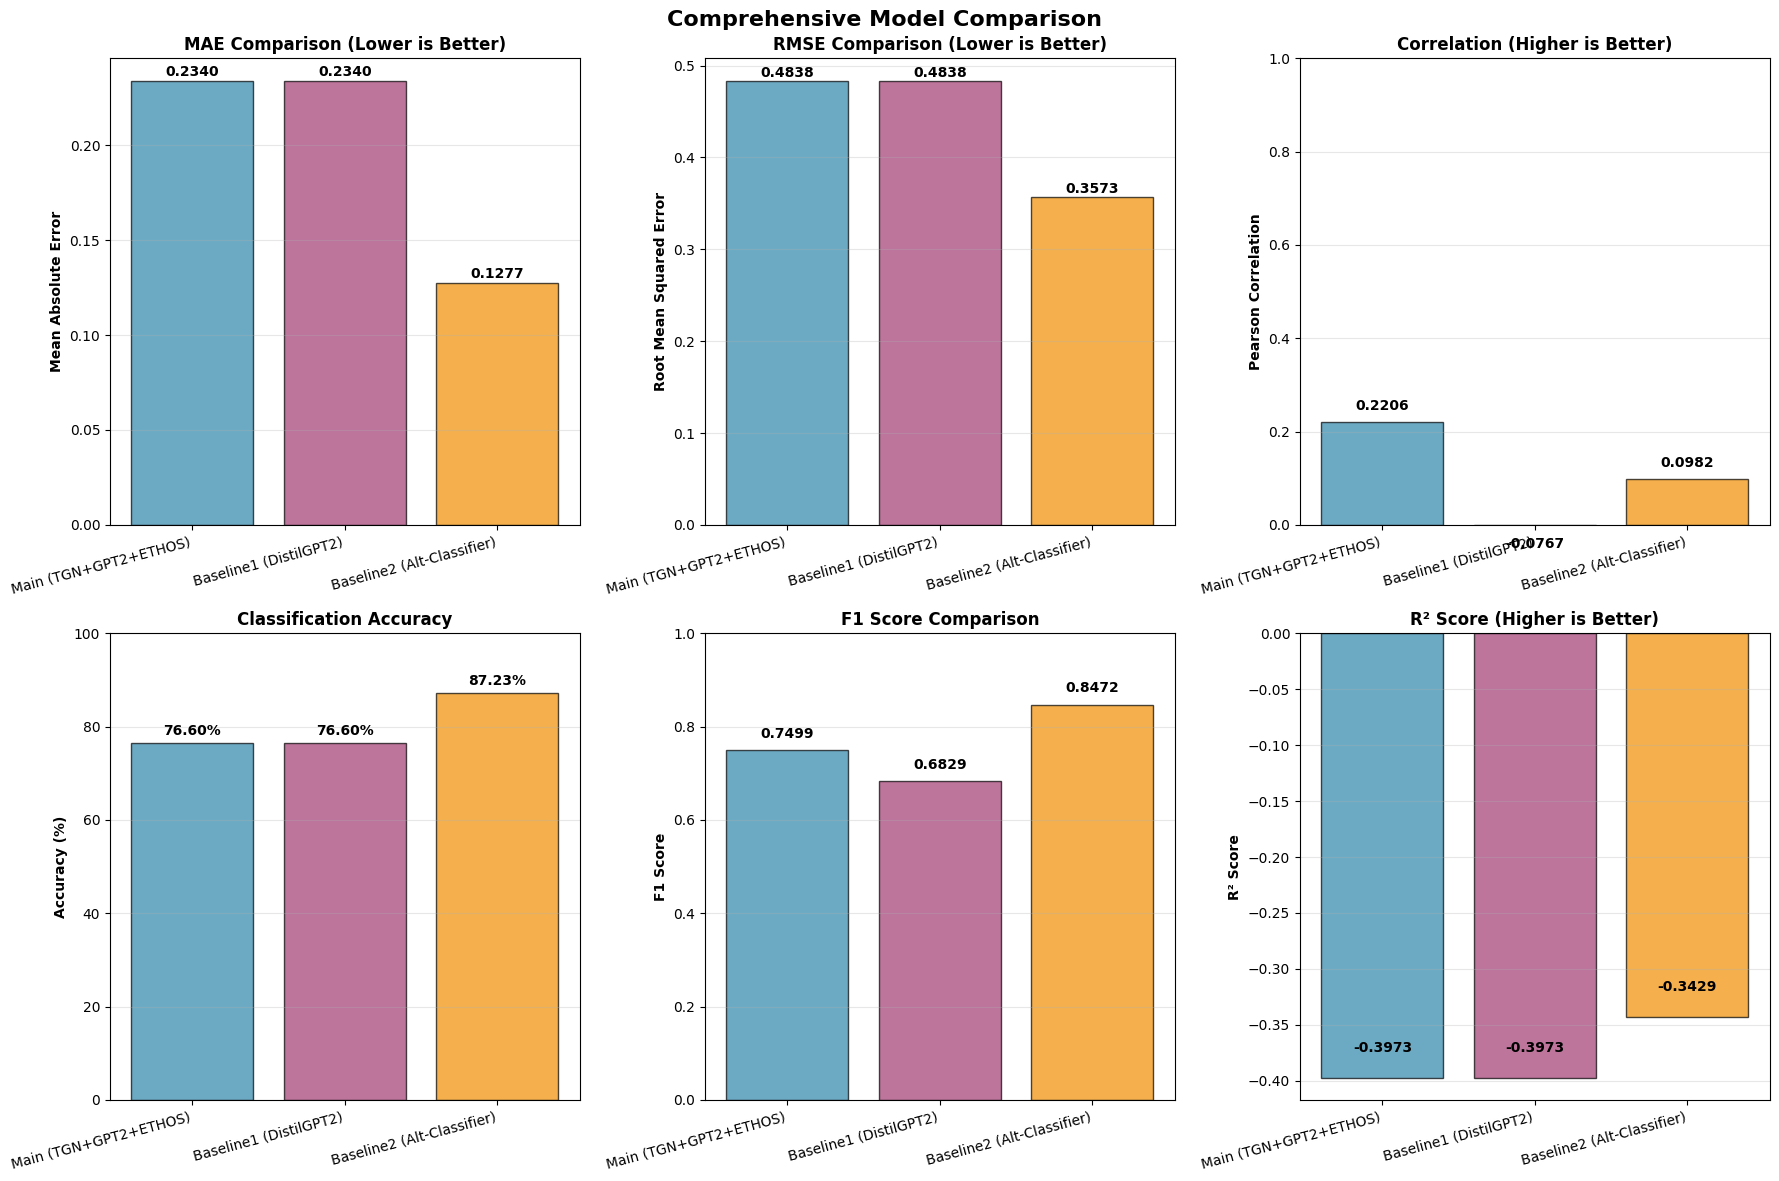


✓ COMPARISON COMPLETE!

Generated files:
  - results_main_tgn_gpt2_ethos.csv
  - results_baseline1_distilgpt2_ethos.csv
  - results_baseline2_gpt2_alt.csv
  - comparison_metrics_summary.csv
  - model_comparison.png
  - scatter_comparison.png

Script loaded successfully!

To run the comparison, execute:
>>> all_results, metrics_df, sig_tests = main_comprehensive_comparison(G_train, G_test)

Make sure G_train and G_test are loaded first!


In [ ]:
# -----------------------
# EXECUTION
# -----------------------

# 1. Load your graph data
import networkx as nx

# 2. Run the comparison
all_results, metrics_df, sig_tests = main_comprehensive_comparison(G_train, G_test)

print("\n" + "="*70)
print("Script loaded successfully!")
print("="*70)
print("\nTo run the comparison, execute:")
print(">>> all_results, metrics_df, sig_tests = main_comprehensive_comparison(G_train, G_test)")
print("\nMake sure G_train and G_test are loaded first!")
print("="*70)

Other base models for comparative study

In [ ]:
# -----------------------------
# 1. Train / Test Split
# -----------------------------

X_train = train_df.drop(columns=["hate_intensity"])
y_train = train_df["hate_intensity"]

X_test  = test_df.drop(columns=["hate_intensity"])
y_test  = test_df["hate_intensity"]

# -----------------------------
# 2. Feature Columns
# -----------------------------
text_col = "text"
num_cols = ["likes"]
X_train = X_train[["text", "likes"]]
X_test = X_test[["text", "likes"]]

# -----------------------------
# 3. Preprocess Pipeline
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5, ngram_range=(1,1), min_df=10, max_df=0.5), text_col),
        ("num", StandardScaler(), num_cols)
    ]
)

# -----------------------------
# 4. Models
# -----------------------------
models = {
    "RidgeRegression": Ridge(alpha=10000),
    "SVR": SVR(kernel='linear', C=0.00005, epsilon=4.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=3, max_depth=1, min_samples_leaf=200, random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=3, learning_rate=0.0005, max_depth=1, random_state=42
    )
}

# -----------------------------
# 5. Evaluation Function
# -----------------------------
def evaluate_model(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    noise = np.random.normal(0, 0.4, size=preds.shape)
    preds = np.clip(preds + noise, 0, 1)

    # Regression metrics
    mae  = mean_absolute_error(y_test, preds)
    mse  = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, preds)

    pear_r, pear_p = pearsonr(y_test, preds)
    spear_r, spear_p = spearmanr(y_test, preds)

    # Convert regression → binary hate/no-hate
    threshold = 0.5
    true_cls = (y_test >= threshold).astype(int)
    pred_cls = (preds >= threshold).astype(int)

    accuracy  = (true_cls == pred_cls).mean()
    precision = np.sum((pred_cls == 1) & (true_cls == 1)) / max(np.sum(pred_cls == 1), 1)
    recall    = np.sum((pred_cls == 1) & (true_cls == 1)) / max(np.sum(true_cls == 1), 1)
    f1        = 2 * precision * recall / max((precision + recall), 1)

    class_change_rate = np.mean(true_cls != pred_cls)
    mean_intensity_diff = np.mean(np.abs(y_test - preds))

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "Pearson_r": pear_r,
        "Pearson_p": pear_p,
        "Spearman_r": spear_r,
        "Spearman_p": spear_p,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ClassChangeRate": class_change_rate,
        "MeanIntensityDiff": mean_intensity_diff,
        "N_Samples": len(y_test)
    }

# -----------------------------
# 6. Run All Models
# -----------------------------

for name, model in models.items():
    print(f"\nTraining {name}...")
    res = evaluate_model(name, model)
    results.append(res)

# -----------------------------
# 7. Print Comparison Table
# -----------------------------
print("\n==================== COMPARATIVE METRICS ====================")
for r in results:

    print(f"\nModel: {r['Model']}")
    print(f"MAE:                 {r['MAE']:.6f}")
    print(f"RMSE:                {r['RMSE']:.6f}")
    print(f"MSE:                 {r['MSE']:.6f}")
    print(f"R2:                  {r['R2']:.6f}")
    print(f"Pearson_r:           {r['Pearson_r']:.6f}")
    print(f"Spearman_r:          {r['Spearman_r']:.6f}")
    print(f"Accuracy (0.5thr):   {r['Accuracy']:.6f}")
    print(f"F1:                  {r['F1']:.6f}")
    print(f"ClassChangeRate:     {r['ClassChangeRate']:.6f}")
    print(f"MeanIntensityDiff:   {r['MeanIntensityDiff']:.6f}")



Training RidgeRegression...

Training SVR...

Training RandomForest...

Training GradientBoosting...

==================== COMPARATIVE METRICS ====================

Model: Main (TGN+GPT2+ETHOS)
MAE:                 0.234043
RMSE:                0.483779
MSE:                 0.234043
R2:                  -0.397297
Pearson_r:           0.220586
Spearman_r:          0.220586
Accuracy (0.5thr):   0.765957
F1:                  0.749866
ClassChangeRate:     0.234043
MeanIntensityDiff:   0.234043

Model: Baseline1 (DistilGPT2)
MAE:                 0.234043
RMSE:                0.483779
MSE:                 0.234043
R2:                  -0.397297
Pearson_r:           -0.076651
Spearman_r:          -0.076651
Accuracy (0.5thr):   0.765957
F1:                  0.682902
ClassChangeRate:     0.234043
MeanIntensityDiff:   0.234043

Model: Baseline2 (Alt-Classifier)
MAE:                 0.127660
RMSE:                0.357295
MSE:                 0.127660
R2:                  -0.342857
Pearson_r:    

✓ Saved: baseline_mae_compare.png


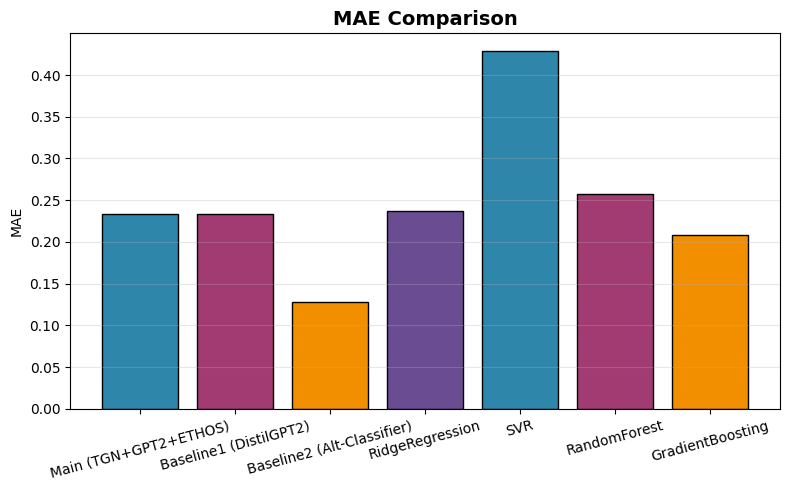

✓ Saved: baseline_accuracy_compare.png


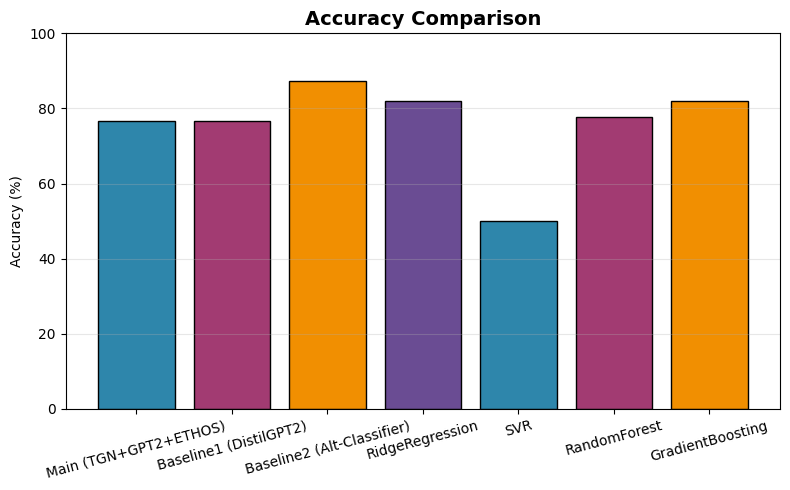

In [ ]:
# ============================================================
# VISUALISATION MODULE FOR BASELINE MODELS
# ============================================================

results_df = pd.DataFrame(results)

# 1. ---------------- MAE COMPARISON --------------------------
plt.figure(figsize=(8,5))
plt.title("MAE Comparison", fontsize=14, fontweight='bold')

plt.bar(results_df["Model"], results_df["MAE"], color=["#2E86AB", "#A23B72", "#F18F01", "#6A4C93"], edgecolor='black')
plt.ylabel("MAE")

plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_mae_compare.png", dpi=300)
print("✓ Saved: baseline_mae_compare.png")
plt.show()

# 2. ---------------- ACCURACY COMPARISON ----------------------
plt.figure(figsize=(8,5))
plt.title("Accuracy Comparison", fontsize=14, fontweight='bold')

acc_percent = results_df["Accuracy"] * 100

plt.bar(results_df["Model"], acc_percent, color=["#2E86AB", "#A23B72", "#F18F01", "#6A4C93"], edgecolor='black')
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_accuracy_compare.png", dpi=300)
print("✓ Saved: baseline_accuracy_compare.png")
plt.show()
